# Task 1.1 - Modal → Amodal Mask Prediction Baseline

In [ ]:
# !tar -xvzf content\69ab82ff9c014fb08291f114f116e183.tar.gz

x 69ab82ff9c014fb08291f114f116e183/
x 69ab82ff9c014fb08291f114f116e183/camera_0003/
x 69ab82ff9c014fb08291f114f116e183/camera_0003/depth_00005.tiff
x 69ab82ff9c014fb08291f114f116e183/camera_0003/rgba_00020.png
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/depth_00012.tiff
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/rgba_00002.png
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/depth_00023.tiff
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/rgba_00005.png
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/segmentation_00008.png
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/segmentation_00006.png
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/segmentation_00001.png
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/depth_00016.tiff
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/segmentation_00010.png
x 69ab82ff9c014fb08291f114f116e183/camera_0003/obj_0007/

In [ ]:
# Data splitting 

from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from pprint import pprint

# Dataset class with safe pair matching
class VideoContextSegmentationDataset(Dataset):
    def __init__(self, root_path):
        self.obj_paths = [f for f in root_path.rglob("obj_*")]
        # print(len(self.obj_paths))
        self.frames = 24

        assert len(self.obj_paths) > 0, "No matched obj paths found."

        self.transform_img = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor()
        ])
        self.transform_mask = transforms.Resize((256, 256))

    def __len__(self):
        return len(self.obj_paths) * self.frames

    def __getitem__(self, idx):
        obj = self.obj_paths[idx // self.frames]
        frame = idx % self.frames

        # Get window of 5 frames centered on `frame`, with mirrored padding
        indices = self._get_frame_window(frame)

        input_stack = []

        for f in indices:
            rgb_path = obj.parent / f"rgba_{f:05d}.png"
            seg_path = obj.parent / f"segmentation_{f:05d}.png"

            rgba = Image.open(rgb_path).convert("RGB")
            seg_np = np.array(Image.open(seg_path))
            obj_id = int(obj.name.split("_")[1])
            seg_mask = (seg_np == obj_id).astype(np.uint8)
            seg_img = Image.fromarray(seg_mask * 255)

            rgba_tensor = self.transform_img(rgba)
            seg_tensor = self.transform_img(seg_img)

            input_stack.append(torch.cat([rgba_tensor, seg_tensor], dim=0))  # 4 channels per frame

        input_tensor = torch.cat(input_stack, dim=0)  # 20 channels

        # Target is amodal mask of center frame
        center = indices[2]
        amod_path = obj / f"segmentation_{center:05d}.png"
        amod = Image.open(amod_path).convert("L")
        output = torch.from_numpy(np.array(self.transform_mask(amod)))
        output = (output > 0).long()

        return input_tensor, output

    def _get_frame_window(self, idx):
        if idx == 0:
            return [2, 1, 0, 1, 2]
        elif idx == 1:
            return [0, 0, 1, 2, 3]
        elif idx == self.frames - 2:
            return [self.frames - 4, self.frames - 3, self.frames - 2, self.frames - 1, self.frames - 1]
        elif idx == self.frames - 1:
            return [self.frames - 3, self.frames - 2, self.frames - 1, self.frames - 2, self.frames - 3]
        else:
            return [idx - 2, idx - 1, idx, idx + 1, idx + 2]



12384


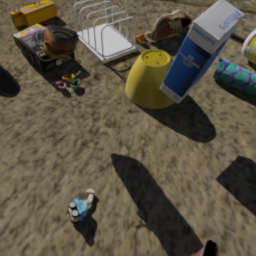

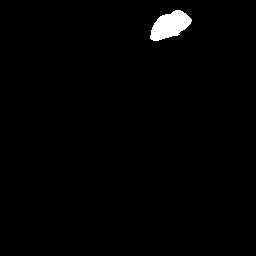

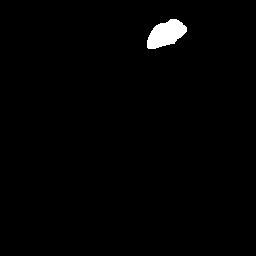

torch.Size([256, 256])

In [4]:
root_path = Path(fr"content")
dataset = VideoContextSegmentationDataset(root_path)
from torchvision.transforms import ToPILImage
to_pil = ToPILImage()
print(len(dataset))
n=722
display(to_pil(dataset[n][0][:3]))  # RGB image
display(to_pil(dataset[n][0][3]))   # Single channel image
display(to_pil(dataset[n][1].float()))      # Label or mask
dataset[n][1].shape

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=False):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.insert(3, nn.Dropout2d(0.3))  # Drop between convs
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=2, base_channels=64, use_transpose=True):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base_channels)
        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.enc3 = ConvBlock(base_channels * 2, base_channels * 4, dropout=True)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(base_channels * 4, base_channels * 8, dropout=True)

        # Decoder
        self.up1 = self._upsample(base_channels * 8, base_channels * 4, use_transpose)
        self.dec1 = ConvBlock(base_channels * 8, base_channels * 4)

        self.up2 = self._upsample(base_channels * 4, base_channels * 2, use_transpose)
        self.dec2 = ConvBlock(base_channels * 4, base_channels * 2)

        self.up3 = self._upsample(base_channels * 2, base_channels, use_transpose)
        self.dec3 = ConvBlock(base_channels * 2, base_channels)

        self.final = nn.Conv2d(base_channels, out_channels, kernel_size=1)

        self._init_weights()

    def _upsample(self, in_ch, out_ch, use_transpose):
        if use_transpose:
            return nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        else:
            return nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(in_ch, out_ch, kernel_size=1)
            )

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d1 = self.up1(b)
        d1 = torch.cat([d1, e3], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, e1], dim=1)
        d3 = self.dec3(d3)

        return self.final(d3)


In [6]:
# IoU
def compute_iou(pred_mask: torch.Tensor, true_mask: torch.Tensor) -> torch.Tensor:
    # print(pred_mask.shape)
    pred_mask = pred_mask.bool()
    true_mask = true_mask.bool()
    intersection = ((pred_mask & true_mask).sum()).float()
    union = ((pred_mask | true_mask).sum()).float()

    return (intersection + 1e-6) / (union + 1e-6)

# Training
def train_model(model, dataloader, device, start_epoch = 0, epochs=5):

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(start_epoch, start_epoch + epochs):
        total_loss = 0.0
        total_iou = 0.0
        for img, mask in tqdm(dataloader):
            # print(img.shape)  # expect [batch_size, 4, 256, 256]
            # print(mask.shape) # expect [batch_size, 256, 256]
            # print(mask.min(), mask.max())  # should be 0 and 1
            img, mask = img.to(device), mask.to(device)
            optimizer.zero_grad()
            out = model(img)
            loss = criterion(out, mask)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            out = (torch.softmax(out, dim=1)[:, 1, :, :] > 0.5)

            total_iou += compute_iou(out, mask).item()
        print(f"Epoch {epoch+1}: Loss = {total_loss/len(dataloader):.4f}, IoU = {total_iou/len(dataloader):.4f}")

# Evaluation
def evaluate_model(model, dataloader, device):
    model.eval()
    total_iou = 0.0
    with torch.no_grad():
        for img, mask in tqdm(dataloader):
            img, mask = img.to(device), mask.to(device)
            out = model(img)
            out = (torch.softmax(out, dim=1)[:, 1, :, :] > 0.5)


            total_iou += compute_iou(out, mask).item()
    print(f"Test IoU = {total_iou / len(dataloader):.4f}")



In [ ]:
#Main script for fresh start
root_path = Path(fr"content")
dataset = VideoContextSegmentationDataset(root_path)

# Split into train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = random_split(dataset, [train_size, test_size])

print(f"Train size: {len(train_set)}, Test size: {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(in_channels=20, out_channels=2).to(device)

# Train and evaluate
train_model(model, train_loader, device, start_epoch=8, epochs=1)
evaluate_model(model, test_loader, device)

552
Train size: 10598, Test size: 2650


100%|██████████| 663/663 [09:03<00:00,  1.22it/s]


Epoch 9: Loss = 0.0092, IoU = 0.8512


100%|██████████| 166/166 [01:16<00:00,  2.16it/s]

Test IoU = 0.8646


In [7]:
current_epoch = 28

In [17]:
# resuming training  
root_path = Path(fr"content")
dataset = VideoContextSegmentationDataset(root_path)

# Split into train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = random_split(dataset, [train_size, test_size])

print(f"Train size: {len(train_set)}, Test size: {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16)

epochs = 8
train_model(model, train_loader, device, start_epoch=current_epoch, epochs=epochs)
current_epoch += epochs
evaluate_model(model, test_loader, device)

torch.save(model.state_dict(), fr"weights\2_1_7_weights_batch16.pth")


Train size: 9907, Test size: 2477


100%|██████████| 620/620 [09:39<00:00,  1.07it/s]


Epoch 29: Loss = 0.0079, IoU = 0.8748


100%|██████████| 620/620 [10:08<00:00,  1.02it/s]


Epoch 30: Loss = 0.0069, IoU = 0.8869


...

Epoch 35: Loss = 0.0055, IoU = 0.9064


100%|██████████| 620/620 [07:45<00:00,  1.33it/s]


Epoch 36: Loss = 0.0053, IoU = 0.9070


100%|██████████| 155/155 [01:22<00:00,  1.89it/s]

Test IoU = 0.9051


In [18]:
evaluate_model(model, test_loader, device)

100%|██████████| 155/155 [00:50<00:00,  3.05it/s]

Test IoU = 0.9051


Idx 144 | Original IoU: 0.885 → New IoU: 0.862


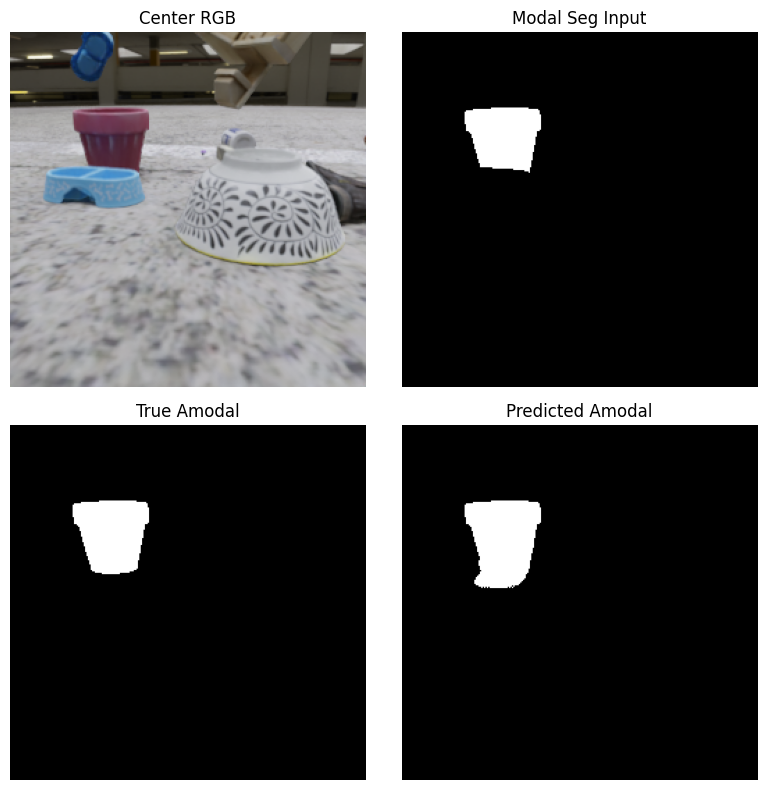

Idx 145 | Original IoU: 0.885 → New IoU: 0.862


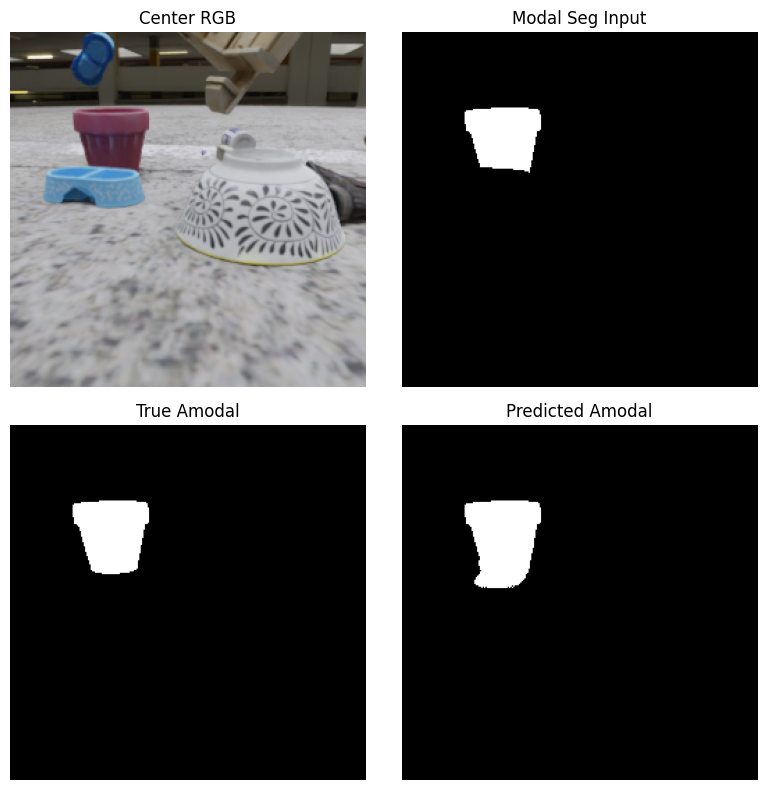

Idx 146 | Original IoU: 0.885 → New IoU: 0.860


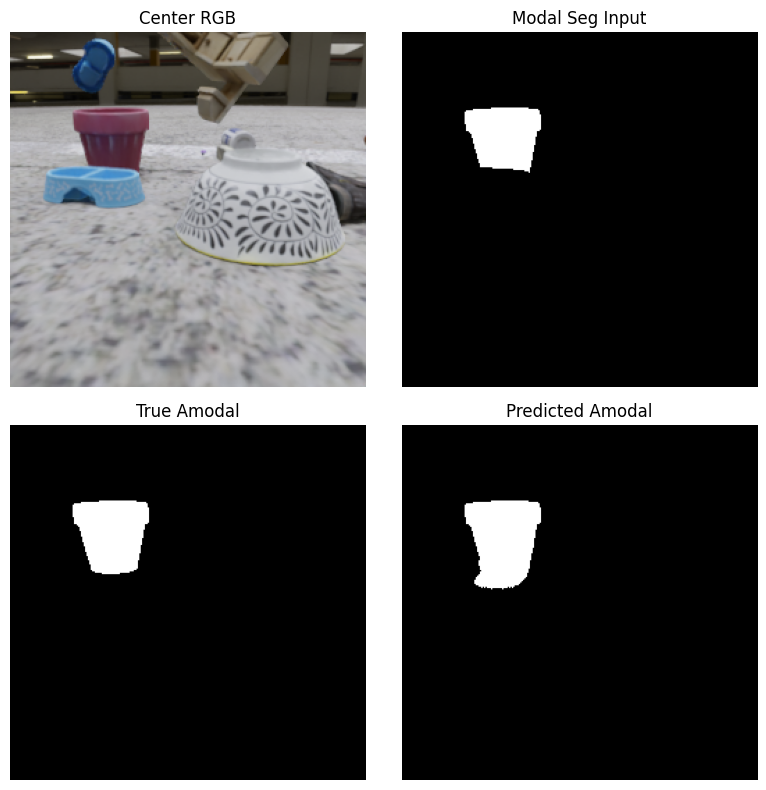

Idx 147 | Original IoU: 0.885 → New IoU: 0.858


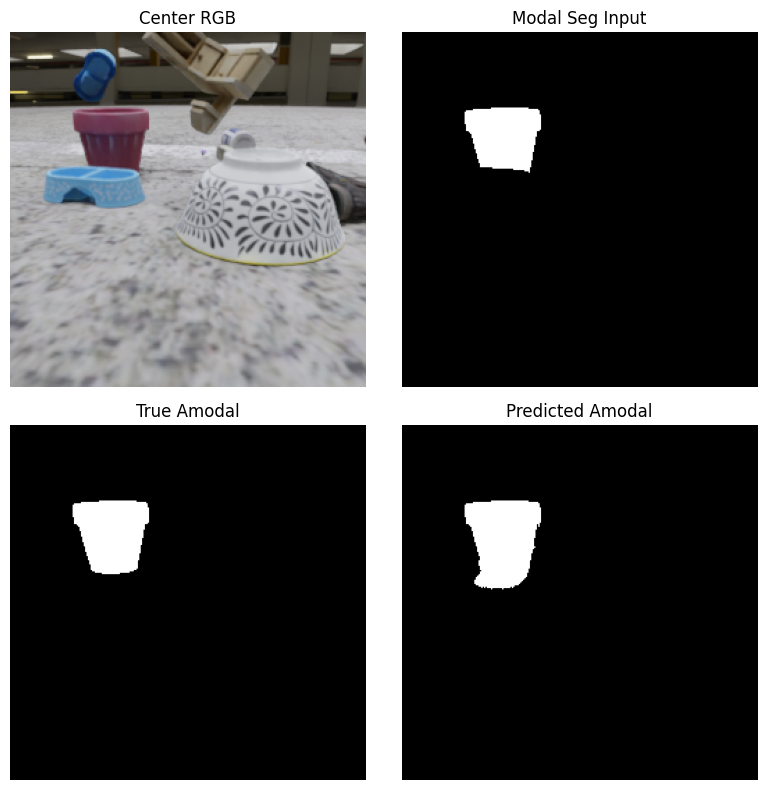

Idx 148 | Original IoU: 0.867 → New IoU: 0.840


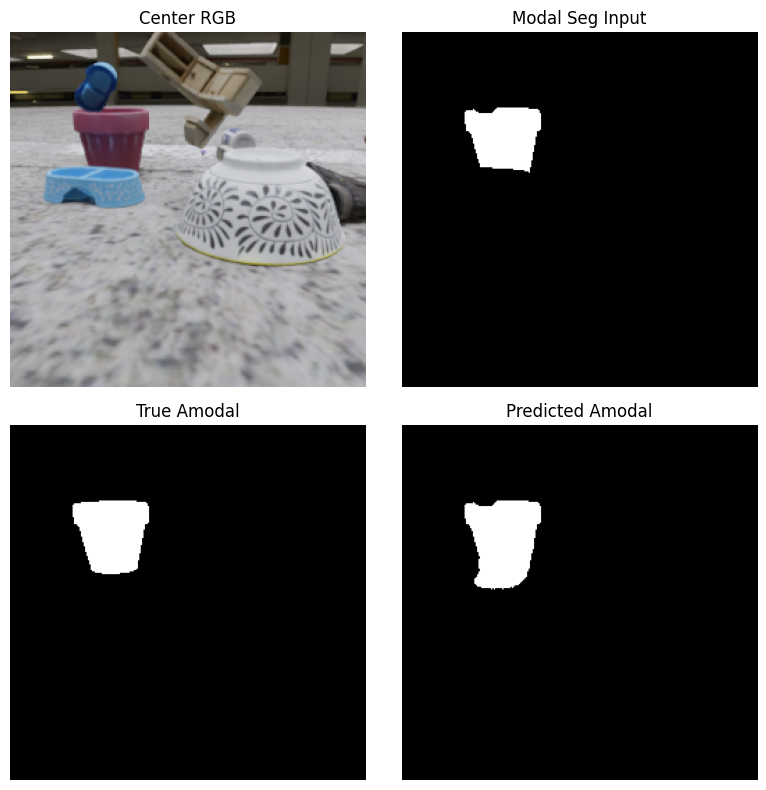

Idx 149 | Original IoU: 0.868 → New IoU: 0.804


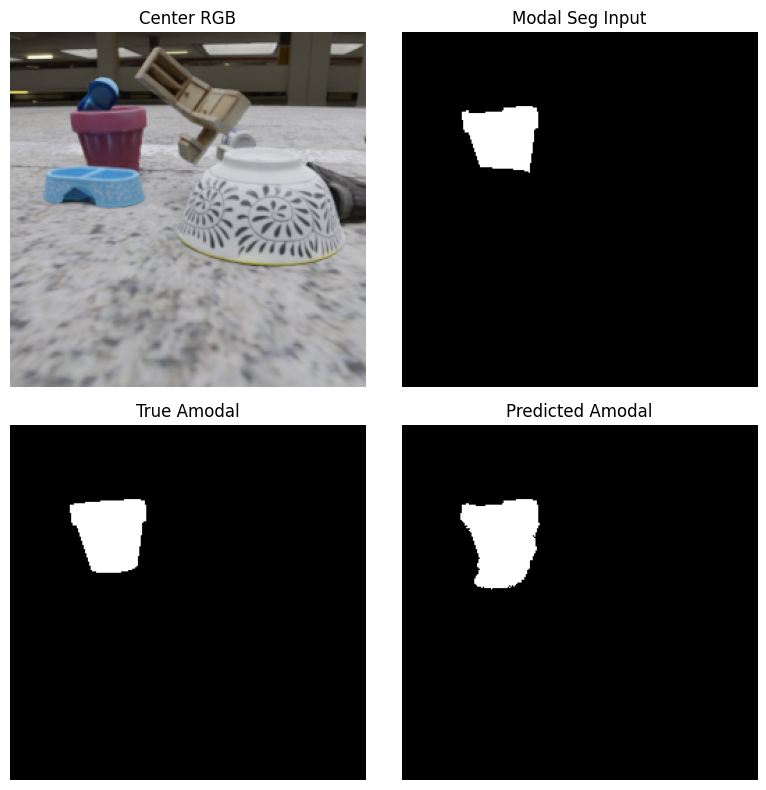

Idx 150 | Original IoU: 0.898 → New IoU: 0.844


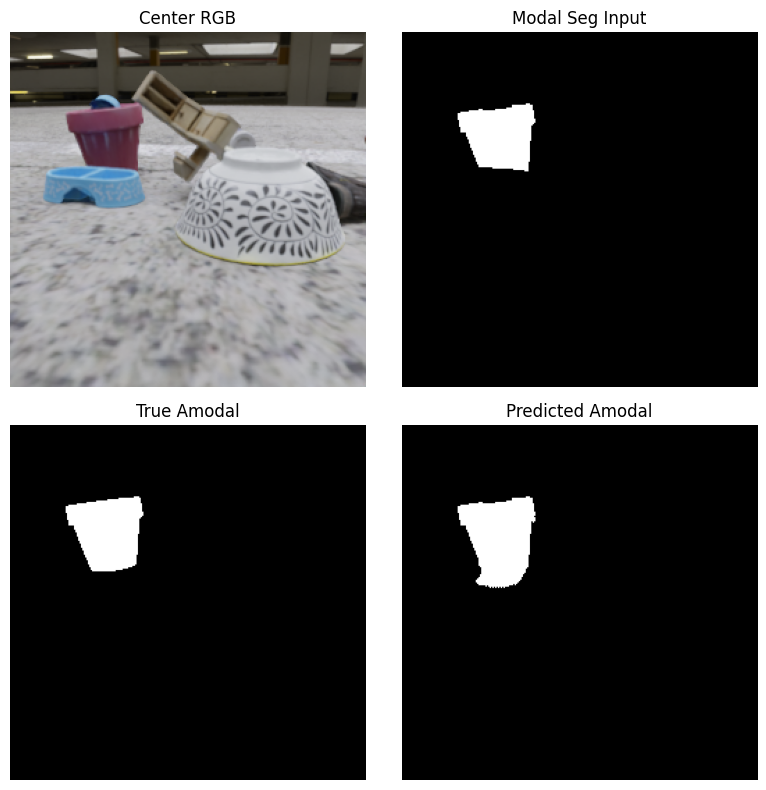

Idx 151 | Original IoU: 0.890 → New IoU: 0.854


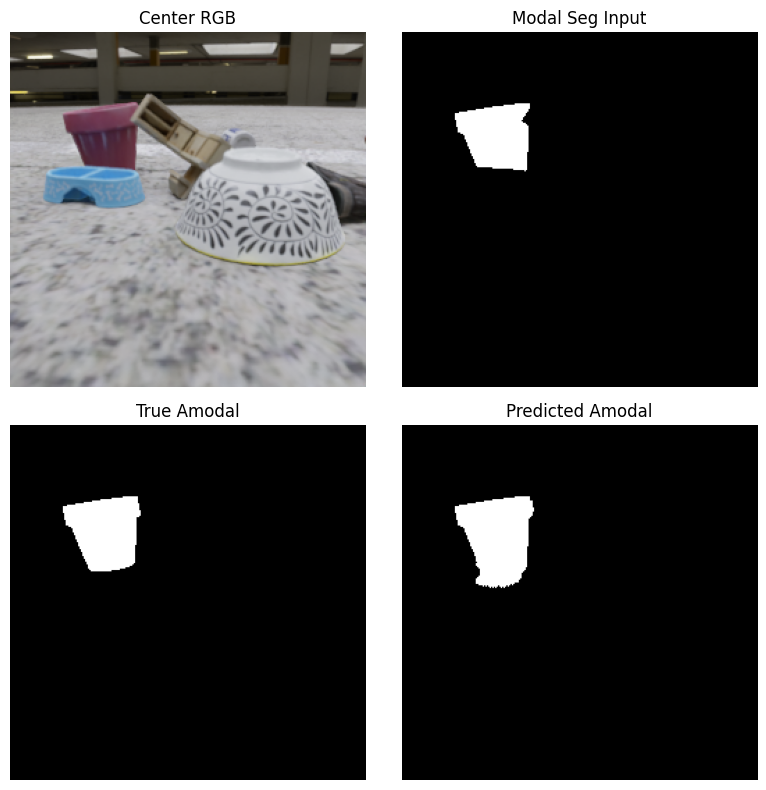

Idx 152 | Original IoU: 0.836 → New IoU: 0.864


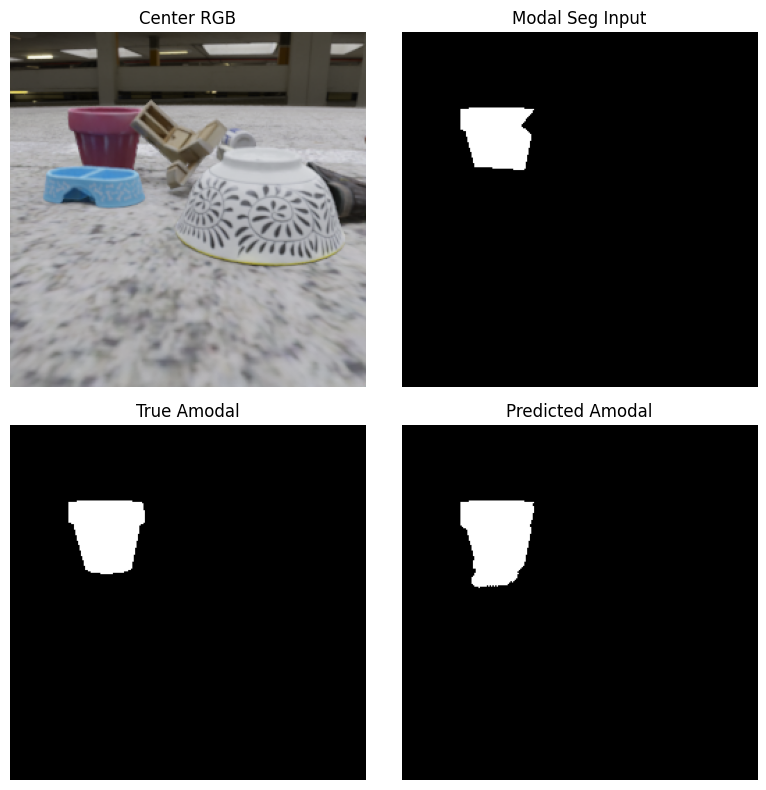

Idx 153 | Original IoU: 0.868 → New IoU: 0.846


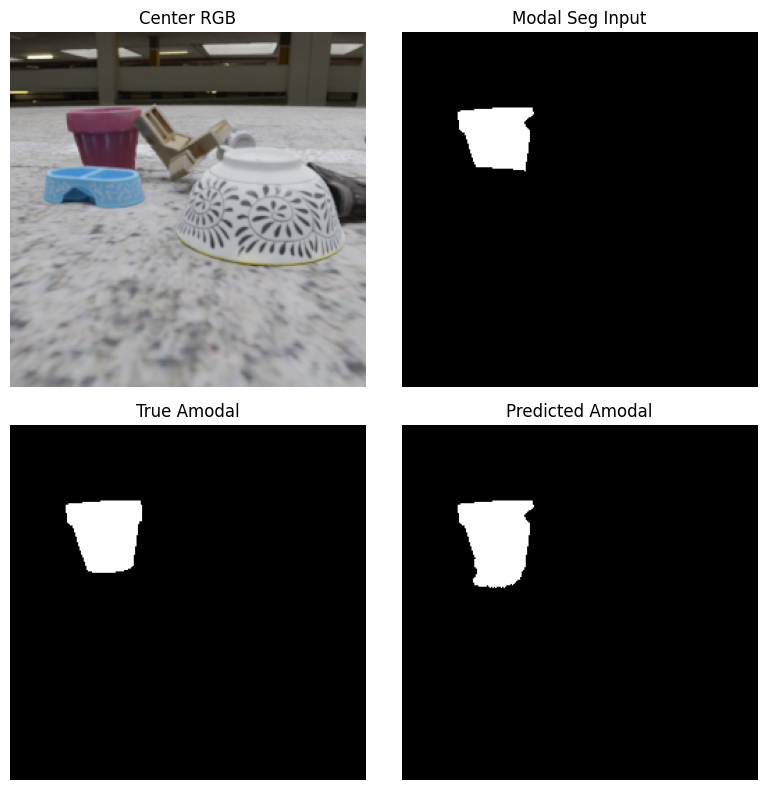

Idx 154 | Original IoU: 0.884 → New IoU: 0.902


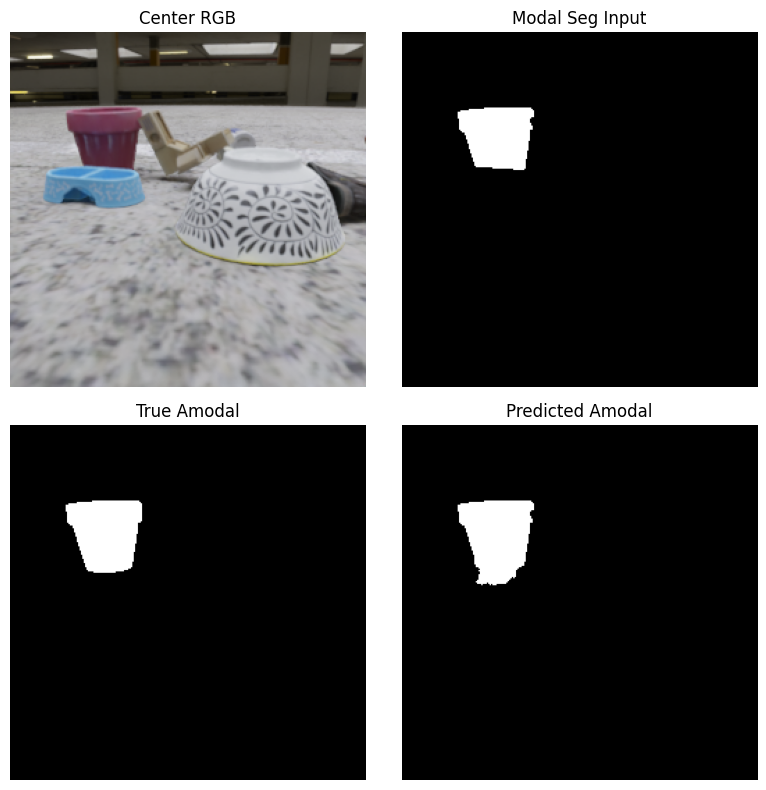

Idx 155 | Original IoU: 0.891 → New IoU: 0.884


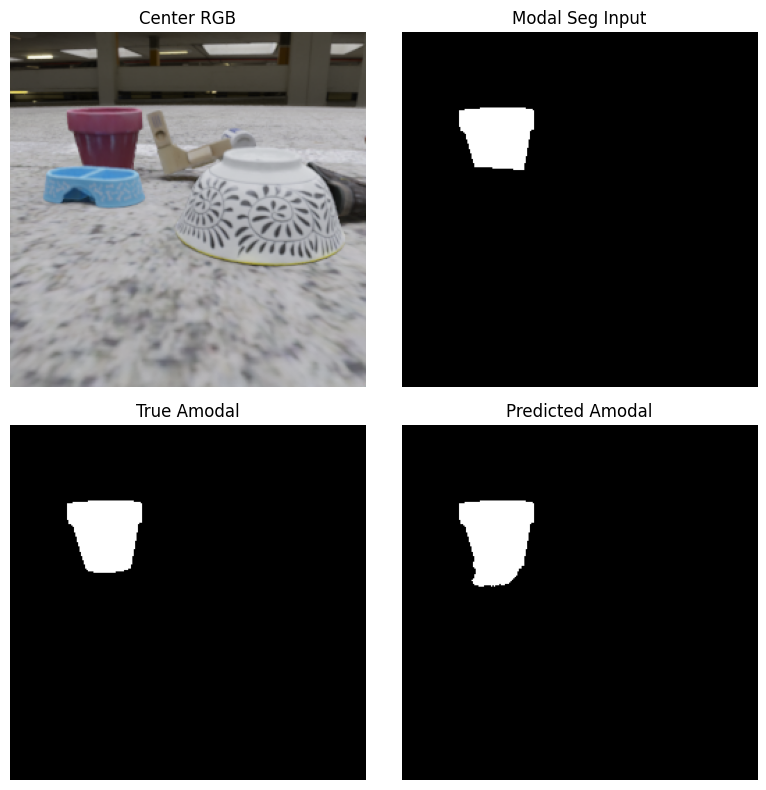

Idx 156 | Original IoU: 0.893 → New IoU: 0.896


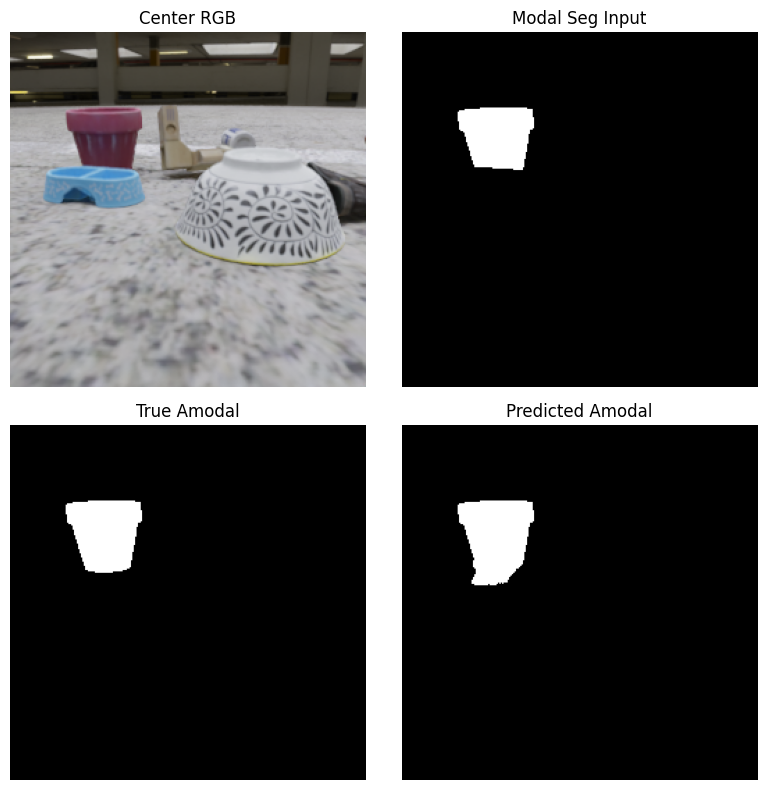

Idx 157 | Original IoU: 0.892 → New IoU: 0.887


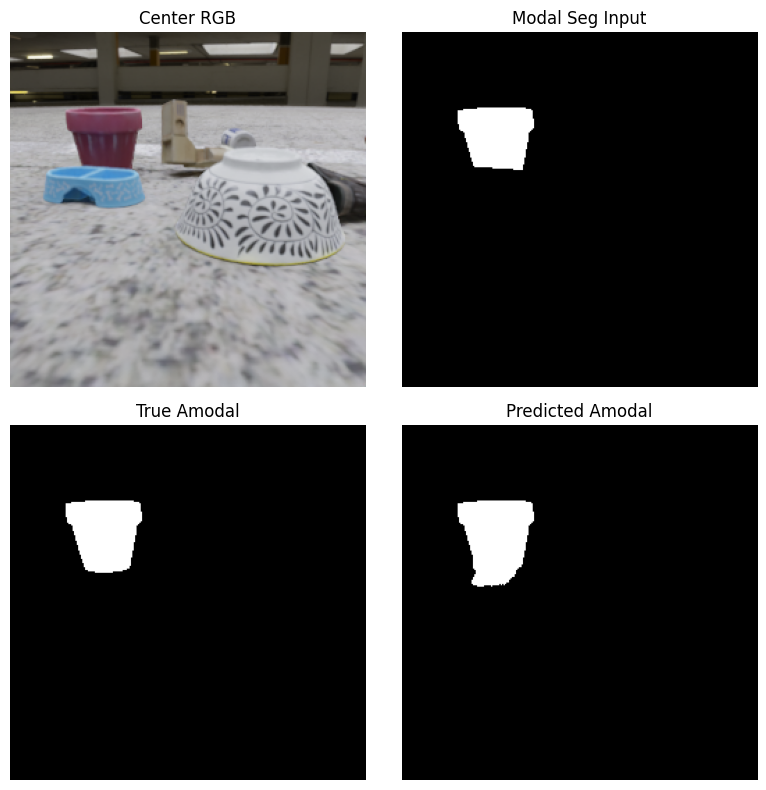

Idx 158 | Original IoU: 0.895 → New IoU: 0.905


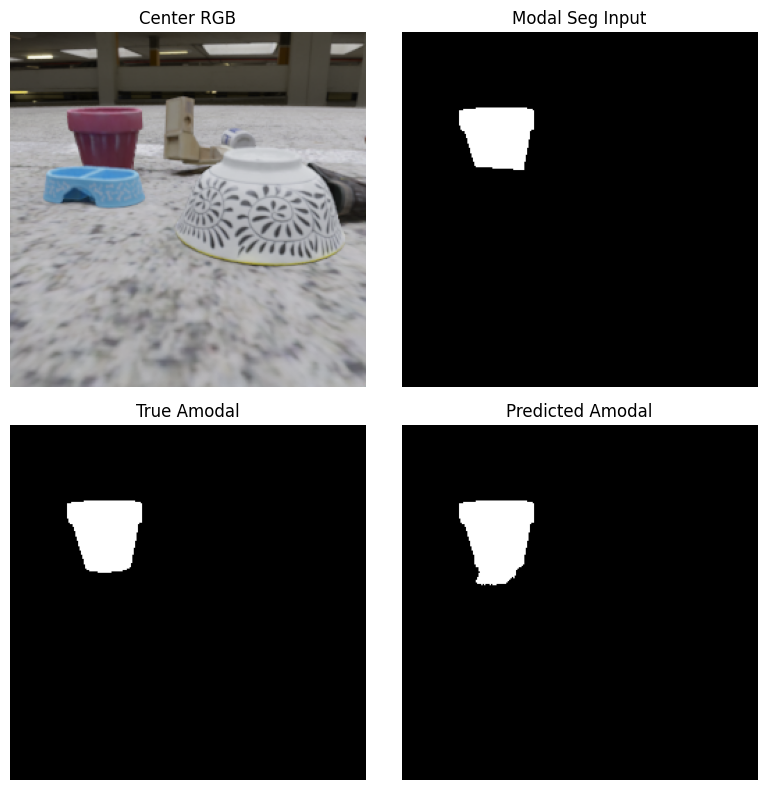

Idx 159 | Original IoU: 0.901 → New IoU: 0.882


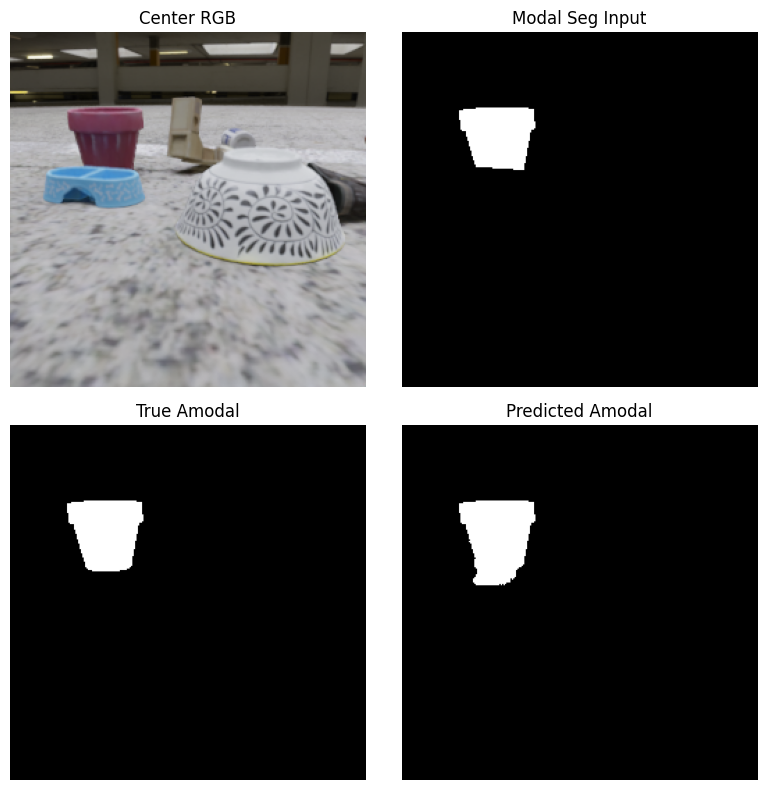

Idx 160 | Original IoU: 0.904 → New IoU: 0.880


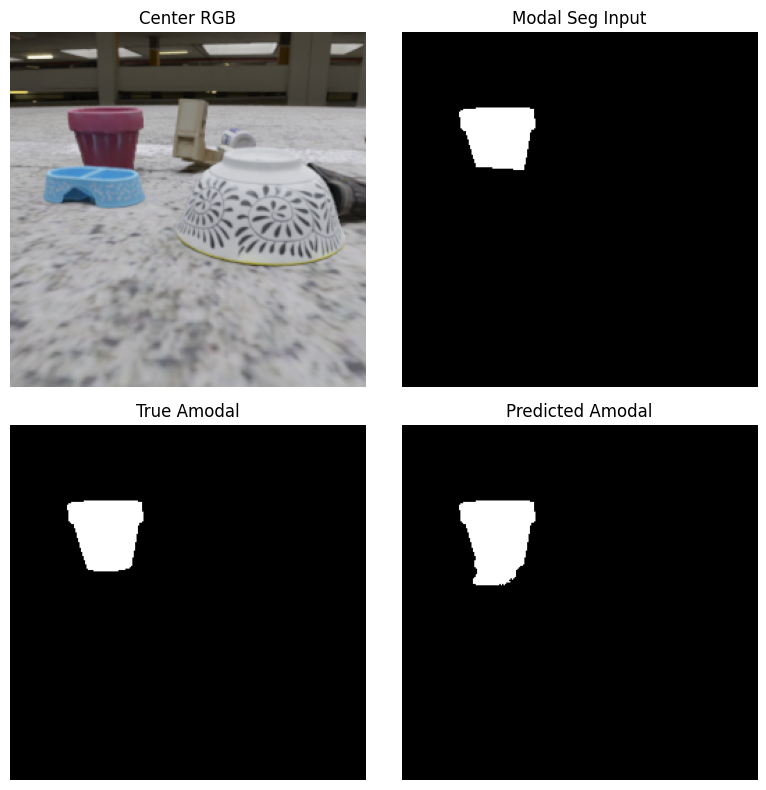

Idx 161 | Original IoU: 0.906 → New IoU: 0.886


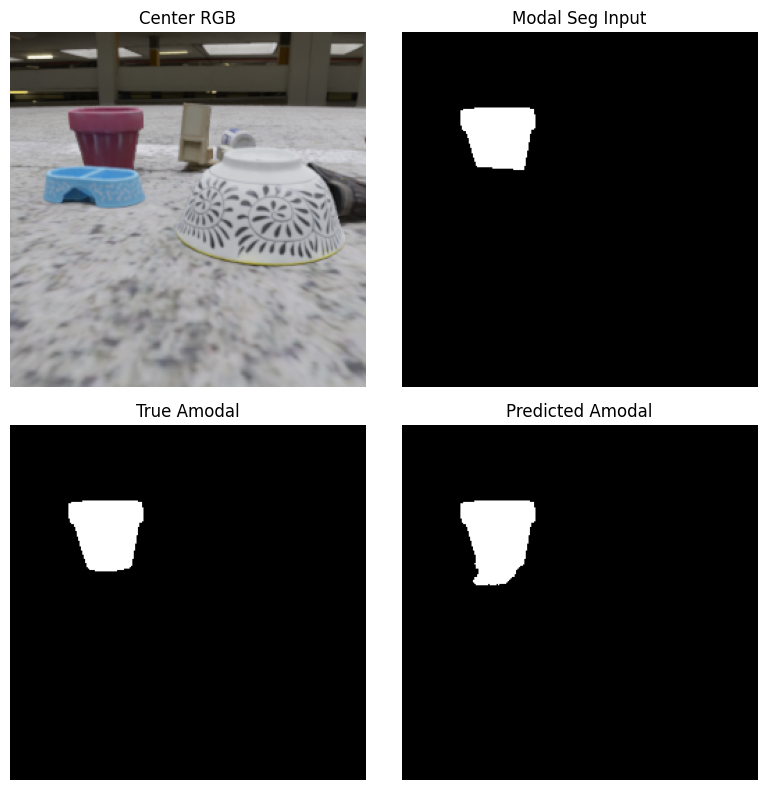

Idx 162 | Original IoU: 0.907 → New IoU: 0.895


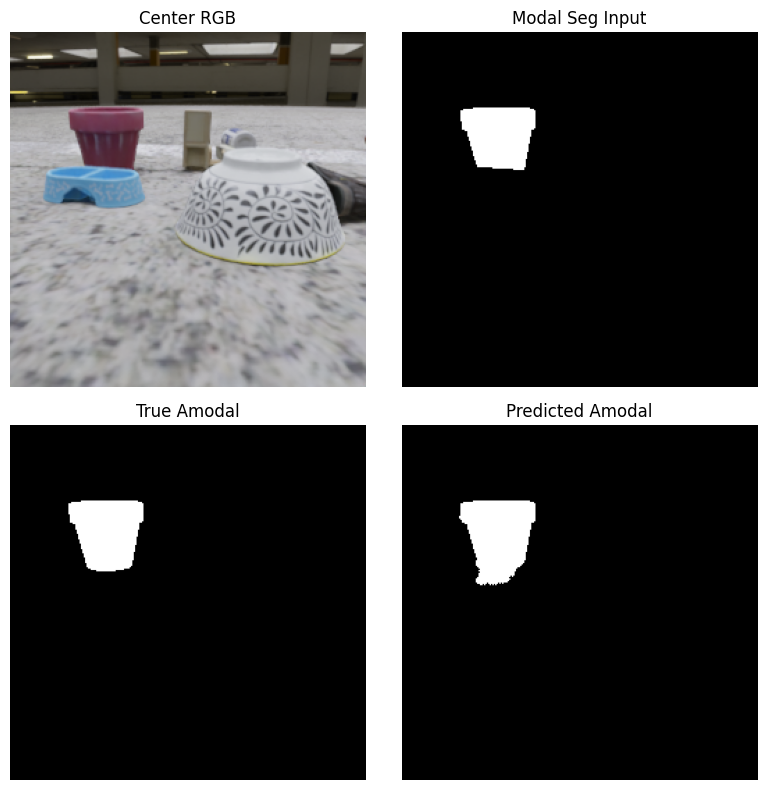

Idx 163 | Original IoU: 0.908 → New IoU: 0.891


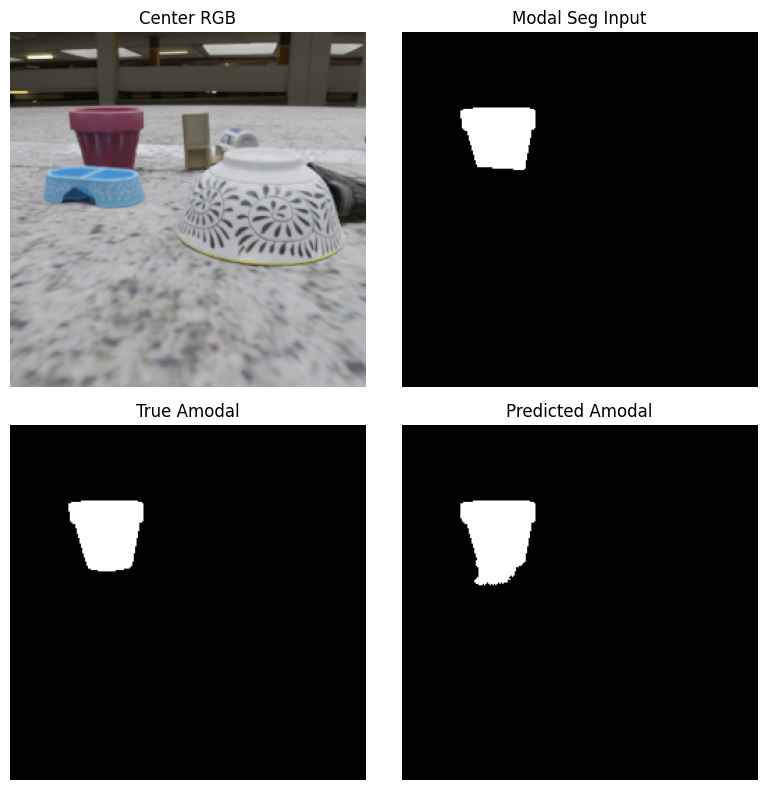

Idx 164 | Original IoU: 0.908 → New IoU: 0.893


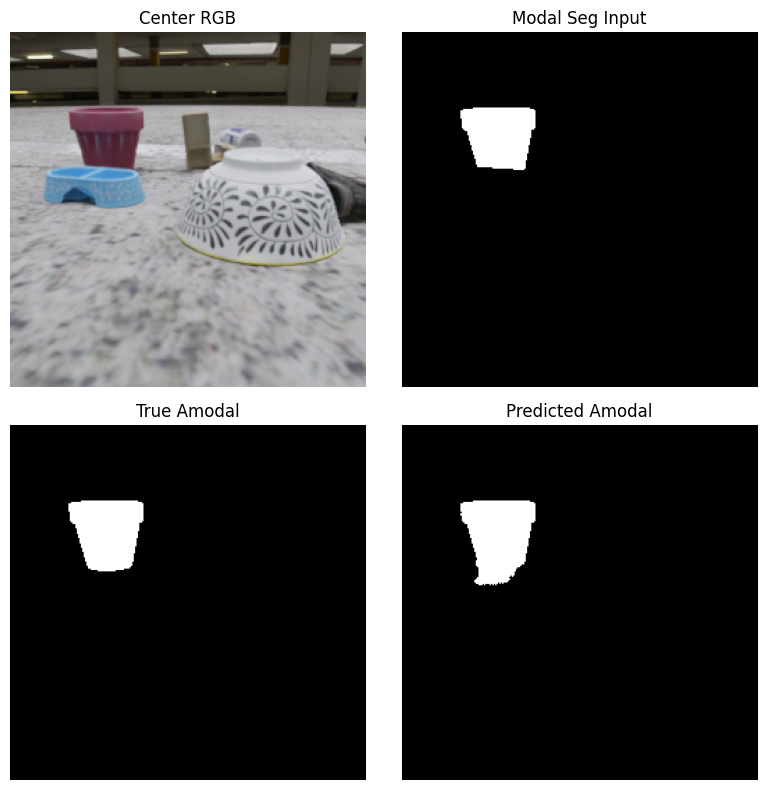

Idx 165 | Original IoU: 0.908 → New IoU: 0.891


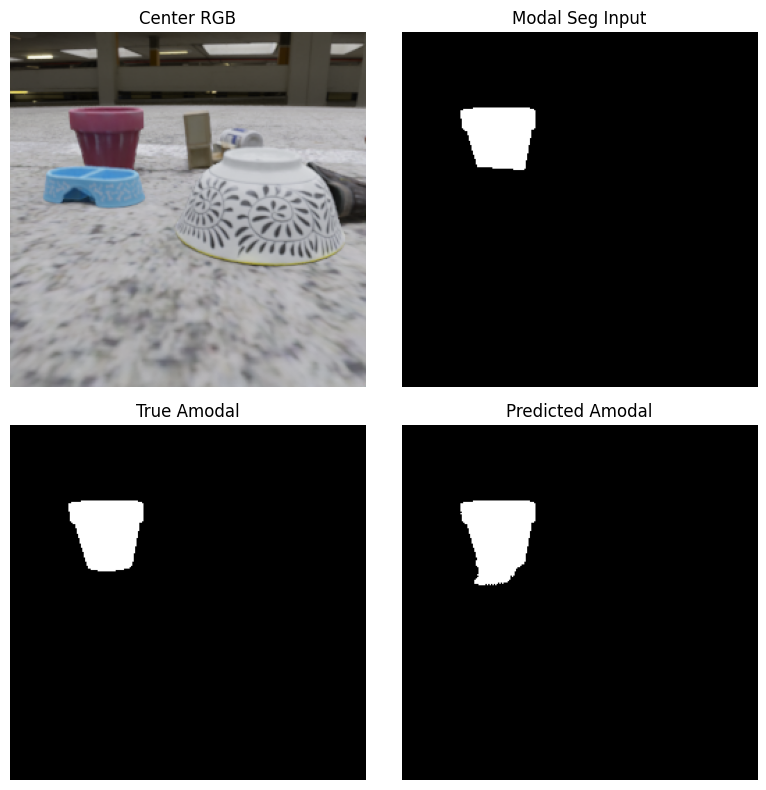

Idx 166 | Original IoU: 0.908 → New IoU: 0.893


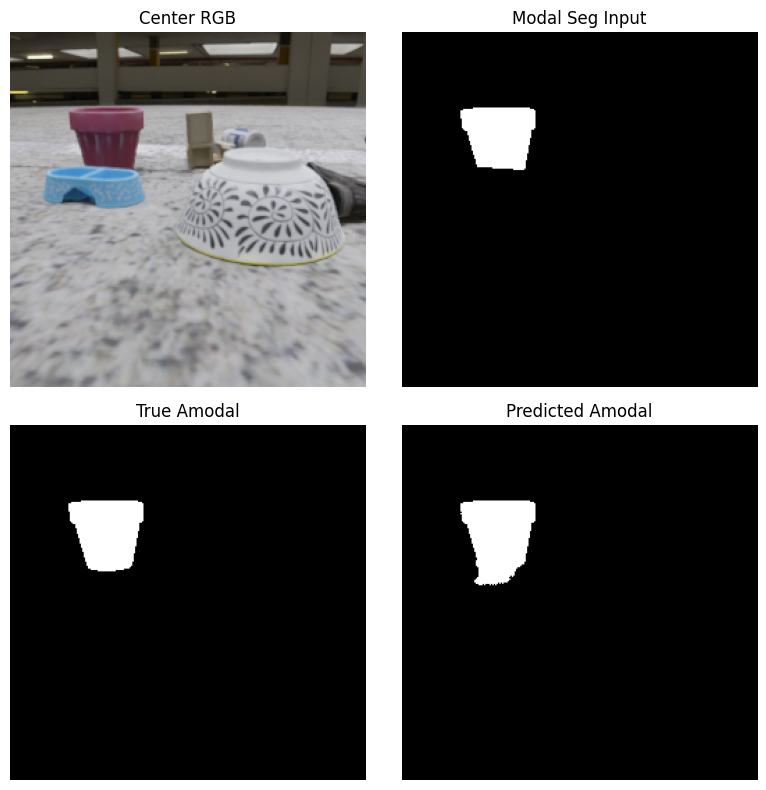

Idx 167 | Original IoU: 0.908 → New IoU: 0.893


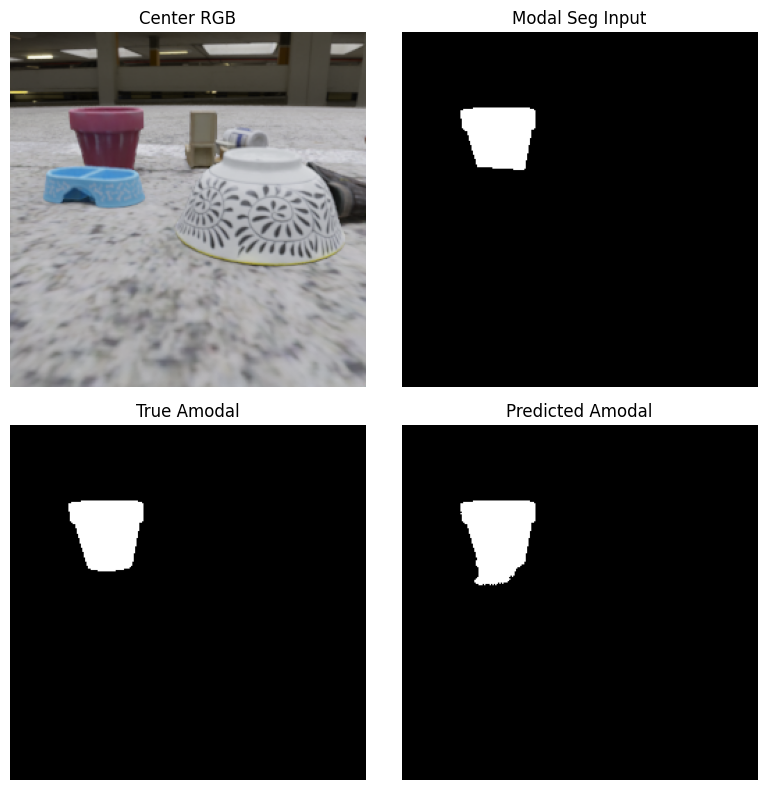

In [16]:
def visualize_prediction(model, dataset, device, idx=0, improvement_threshold=0.3):
    model.eval()
    input_tensor, true_mask = dataset[idx]
    input_tensor = input_tensor.unsqueeze(0).to(device)  # Add batch dimension
    true_mask = true_mask.to(device)

    with torch.no_grad():
        pred_logits = model(input_tensor)
        pred_mask = torch.argmax(pred_logits, dim=1).squeeze(0).cpu()

    # Extract center frame RGB and modal seg
    center_rgb = input_tensor[0, 8:11].cpu()  # channels 8–10 = RGB
    center_seg = input_tensor[0, 11].cpu()    # channel 11 = modal seg

    # Compute IoUs
    original_iou = compute_iou(center_seg.to(device), true_mask).item()
    new_iou = compute_iou(pred_mask.to(device), true_mask).item()


    if new_iou - original_iou > improvement_threshold and original_iou != 1:
        print(f"Idx {idx} | Original IoU: {original_iou:.3f} → New IoU: {new_iou:.3f}")

        fig, axs = plt.subplots(2, 2, figsize=(8, 8))
        axs[0][0].imshow(center_rgb.permute(1, 2, 0))  # C x H x W → H x W x C
        axs[0][0].set_title("Center RGB")

        axs[0][1].imshow(center_seg, cmap="gray")
        axs[0][1].set_title("Modal Seg Input")

        axs[1][0].imshow(true_mask.cpu(), cmap="gray")
        axs[1][0].set_title("True Amodal")

        axs[1][1].imshow(pred_mask, cmap="gray")
        axs[1][1].set_title("Predicted Amodal")

        for ax_row in axs:
            for ax in ax_row:
                ax.axis('off')
        plt.tight_layout()
        plt.show()

test_scene = VideoContextSegmentationDataset(Path("test"))

# Visualize prediction from test set
for i in range(100, 200):
  visualize_prediction(model, test_scene, device, idx=i, improvement_threshold=-1)

In [19]:
test_scene = VideoContextSegmentationDataset(Path("test"))
test_loader = DataLoader(test_scene, batch_size=1)
evaluate_model(model, test_loader, device)

100%|██████████| 2592/2592 [01:00<00:00, 43.08it/s]

Test IoU = 0.8324


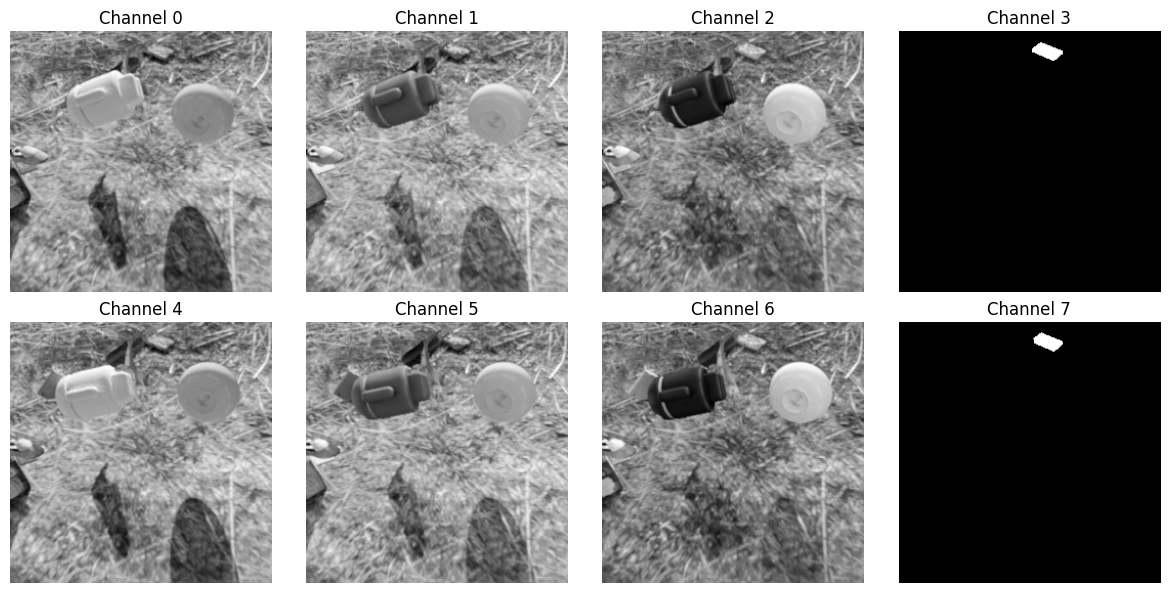

In [27]:
def show_first_8_channels(input_tensor):
    # input_tensor shape: [C, H, W]
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))
    axs = axs.flatten()

    for i in range(8):
        channel_img = input_tensor[i].cpu()
        axs[i].imshow(channel_img, cmap='gray')
        axs[i].set_title(f'Channel {i}')
        axs[i].axis('off')

    plt.tight_layout()
    plt.show()

input_tensor, _ = dataset[0]  # get first sample
show_first_8_channels(input_tensor)

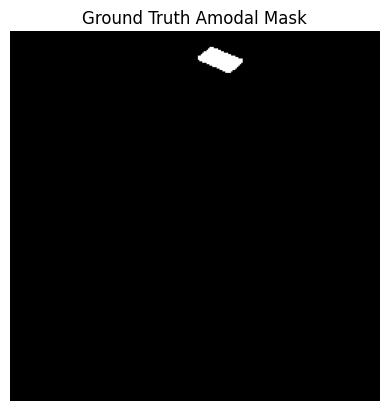

In [30]:
input_tensor, output = dataset[0]

plt.imshow(output.cpu(), cmap='gray')
plt.title("Ground Truth Amodal Mask")
plt.axis('off')
plt.show()

In [18]:
torch.save(model.state_dict(), fr"weights\2_1_5_weights_batch16.pth")


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(in_channels=20, out_channels=2).to(device)
model.load_state_dict(torch.load(fr"weights\2_1_5_weights_batch16.pth"))
model.eval()  # Important for evaluation


UNet(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(20, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): ConvBlock(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size

In [14]:
for i in range(200, 300):
    visualize_prediction(model, test_set, device, idx=i)

NameError: name 'visualize_prediction' is not defined